# 6 · Backtest Biases: Look-Ahead, Survivorship and Overfitting

*Common Core*

Most backtests look better than the strategy will ever perform live. This notebook shows the three main reasons, each measured on our own data.

## 1. Motivation

Search online and you will find hundreds of strategies with beautiful backtests: 30% a year, tiny drawdowns. Very few of them make money once real money goes in. Usually the strategy is not broken. The *backtest* is. It used information that wasn't available at the time, tested only the companies that survived, or tried so many variations that one was bound to look good by chance. Every team in the club needs to catch these problems before presenting a result.

## 2. Intuition

1. **Look-ahead bias.** Using information you would not have had at the time. We saw one version in notebook 4 (the missing `.shift(1)`). Others include using revised economic data, or a news article stamped with the wrong time.
2. **Survivorship bias.** Testing only on assets that still exist today. Companies that went bankrupt or were dropped from the index disappear from the data, so the sample is tilted towards winners. It is like judging the safety of mountaineering by interviewing only climbers who came back.
3. **Overfitting (data snooping).** Trying many rules or parameters and keeping the best. If you flip 1,000 coins ten times each, one of them will probably land heads 9 or 10 times. That doesn't make it a special coin. The more variations you test, the better the best one looks *by luck alone*.

## 3. The math

**How good does luck look?** Suppose a strategy has *no* real edge: its true Sharpe ratio is 0. Estimated from $Y$ years of data, its Sharpe ratio is roughly normally distributed around 0, with standard deviation
$$
\sigma_{SR} \approx \frac{1}{\sqrt{Y}} .
$$
Now test $N$ such strategies and keep the best. If $z_N$ is the expected maximum of $N$ independent standard normal draws, then
$$
\mathbb{E}\big[\max \widehat{SR}\big] \approx \frac{z_N}{\sqrt{Y}} .
$$
$z_N$ grows slowly with $N$: about 1.5 for $N=10$, 2.5 for $N=100$ and 3.2 for $N=1000$. (For very large $N$ it approaches $\sqrt{2\ln N}$.) With about 16.7 years of data and 1,000 strategies tried, the best one is expected to show a Sharpe ratio of about $3.2/\sqrt{16.7} \approx 0.8$, with **zero skill**. That is about what the S&P 500 delivered over the same period.

**The fix: out-of-sample testing.** Split the data in time. Choose the rule on the first part (**in-sample**). Then measure it once on the second part (**out-of-sample**), which played no role in the choice.

## 4. Code it

### 4.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
meta = pd.read_csv("../data/meta.csv")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

returns = prices.drop(columns=["^VIX", "^IRX"]).pct_change().dropna()

def sharpe(r):
    """Annualised Sharpe ratio (risk-free rate ignored for simplicity)."""
    return np.sqrt(252) * r.mean() / r.std()

### 4.2 Survivorship bias in our own dataset

Our 43 stocks were picked in 2026 because they are large, successful companies *today*. An investor in 2010 could not have known which companies would end up on that list. Compare an equal-weight portfolio of these stocks with SPY, which held whatever the 500 largest companies were at each point in time, losers included.

In [2]:
stocks = meta.loc[meta.asset_type == "stock", "ticker"]
survivors = returns[stocks].mean(axis=1)    # equal weight, rebalanced daily

comparison = pd.DataFrame({"Our 43 'survivors'": survivors, "SPY": returns["SPY"]})
years = len(comparison) / 252
summary = pd.DataFrame({
    "CAGR": ((1 + comparison).prod() ** (1 / years) - 1).map("{:.1%}".format),
    "Sharpe": comparison.apply(sharpe).map("{:.2f}".format),
})
summary

,CAGR,Sharpe
Our 43 'survivors',16.8%,1.06
SPY,14.1%,0.86


Our hand-picked stocks beat SPY by almost 3 percentage points a year, with a much higher Sharpe ratio. No strategy produced that gap. We simply chose companies we already knew had done well. Part of the gap could come from other differences (equal weighting, fewer stocks), but hindsight is a big part of it. **Any strategy tested on this universe inherits this tailwind.** That is why later notebooks compare strategies *with each other* on the same universe, rather than claiming they "beat the market".

### 4.3 Overfitting: 1,000 strategies with no skill

Each "strategy" below flips a coin every day to decide whether to be long or short SPY. None of them has any information. We compute all 1,000 Sharpe ratios and compare the best one with the formula from Section 3.

Std of the random Sharpe ratios: 0.25  (theory 1/sqrt(Y) = 0.24)
Best of 1000 random strategies: Sharpe 0.82
Formula z_N / sqrt(Y):             0.79   (z_N = 3.23)
SPY over the same period:          0.86


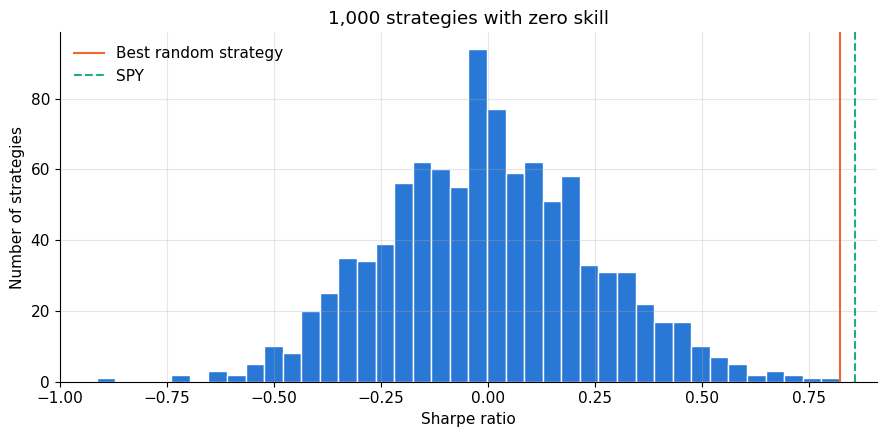

In [3]:
rng = np.random.default_rng(42)
spy = returns["SPY"]
N = 1000

random_sharpes = []
for _ in range(N):
    pos = rng.choice([-1, 1], size=len(spy))   # coin flip each day: long (+1) or short (-1) SPY
    random_sharpes.append(sharpe(pd.Series(pos * spy.values)))
random_sharpes = np.array(random_sharpes)

# z_N: expected maximum of N standard normals, estimated by simulation
z_N = rng.standard_normal((2000, N)).max(axis=1).mean()
expected_best = z_N / np.sqrt(years)                # E[max SR] ~ z_N / sqrt(Y)

print(f"Std of the random Sharpe ratios: {random_sharpes.std():.2f}  (theory 1/sqrt(Y) = {1 / np.sqrt(years):.2f})")
print(f"Best of {N} random strategies: Sharpe {random_sharpes.max():.2f}")
print(f"Formula z_N / sqrt(Y):             {expected_best:.2f}   (z_N = {z_N:.2f})")
print(f"SPY over the same period:          {sharpe(spy):.2f}")

fig, ax = plt.subplots()
ax.hist(random_sharpes, bins=40, color=COLORS[0], edgecolor="white")
ax.axvline(random_sharpes.max(), color=COLORS[1], label="Best random strategy")
ax.axvline(sharpe(spy), color=COLORS[2], ls="--", label="SPY")
ax.set_xlabel("Sharpe ratio")
ax.set_ylabel("Number of strategies")
ax.set_title("1,000 strategies with zero skill")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The random Sharpe ratios spread out with a standard deviation of about 0.25, exactly as $1/\sqrt{Y}$ predicts. The best of the 1,000 coin-flippers reached a Sharpe ratio of about 0.8, almost the same as SPY and close to the formula. If someone shows you "the best of many strategies we tried", this is the bar it must clear before it means anything.

### 4.4 In-sample vs. out-of-sample

A more realistic version: we test the trend rule from notebook 4 with every moving-average length from 20 to 300 days. We choose the best length using 2010–2017 only, then check how it does in 2018–2026.

Best window in-sample: 190 days
  in-sample Sharpe:     0.99
  out-of-sample Sharpe: 0.83
  median out-of-sample Sharpe across all windows: 0.87
  buy-and-hold SPY 2018-2026:                     0.81


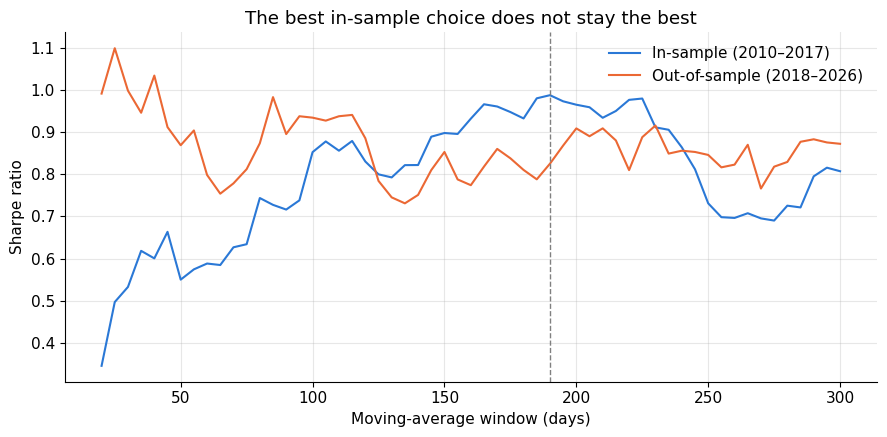

In [4]:
spy_px = prices["SPY"]
rf = (prices["^IRX"].ffill() / 100 / 252).shift(1)
spy_ret = spy_px.pct_change()

results = []
for window in range(20, 301, 5):
    signal = (spy_px > spy_px.rolling(window).mean()).astype(float).shift(1)   # correct timing
    strat = (signal * spy_ret + (1 - signal) * rf).dropna()
    results.append({"window": window,
                    "in_sample": sharpe(strat[:"2017"]),
                    "out_of_sample": sharpe(strat["2018":])})
results = pd.DataFrame(results).set_index("window")

best = results["in_sample"].idxmax()
print(f"Best window in-sample: {best} days")
print(f"  in-sample Sharpe:     {results.loc[best, 'in_sample']:.2f}")
print(f"  out-of-sample Sharpe: {results.loc[best, 'out_of_sample']:.2f}")
print(f"  median out-of-sample Sharpe across all windows: {results['out_of_sample'].median():.2f}")
print(f"  buy-and-hold SPY 2018-2026:                     {sharpe(spy_ret['2018':]):.2f}")

fig, ax = plt.subplots()
ax.plot(results.index, results["in_sample"], label="In-sample (2010–2017)")
ax.plot(results.index, results["out_of_sample"], label="Out-of-sample (2018–2026)")
ax.axvline(best, color="grey", ls="--", linewidth=1)
ax.set_xlabel("Moving-average window (days)")
ax.set_ylabel("Sharpe ratio")
ax.set_title("The best in-sample choice does not stay the best")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The two curves have almost nothing to do with each other. The 190-day window was the best in-sample (Sharpe ≈ 1.0). Out-of-sample it scored about 0.83: below the median window and barely above simply holding SPY. The *short* windows, which looked worst in 2010–2017, did best in 2018–2026. Picking the in-sample winner bought us nothing. The in-sample peak was mostly noise that we fitted.

## 5. Takeaways and where it breaks

- **Look-ahead:** shift positions, and check the timestamp on every piece of data. Ask "could I have known this at the time?"
- **Survivorship:** use a universe that was knowable *at the time*: historical index members, including companies that later failed. Our course dataset does not do this, so treat strategy results on it as optimistic.
- **Overfitting:** count how many things you tried, and compare your best result with what luck alone would produce, about $z_N/\sqrt{Y}$.
- **Keep a test set you only look at once.** If you go back and tweak the rule after seeing the out-of-sample result, that data becomes in-sample too.
- **Where it breaks:** the $z_N/\sqrt{Y}$ formula assumes independent strategies. Variations of the same idea are highly correlated, so the "effective" $N$ is smaller than the number of runs. This is a rule of thumb, not an exact test.

**What you could build:** a research log template for the club: every backtest run gets recorded, so the final presentation can honestly report how many ideas were tried before the winner was found.